# 03 — Sales and operations EDA

## Questions answered
1. How do realized orders and checkout value change over time?
2. Which product categories, customer states, and sellers contribute most?
3. What is the observed delivery performance for completed orders?
4. How do customers pay and use installments?

### Metric definitions
- **Merchandise value:** sum of item `price`; excludes freight.
- **Checkout value:** sum of `price + freight_value`; used as the primary realized-order value.
- **Payment value:** sum of payment records; used for payment behavior and reconciliation, not substituted for checkout value.
- **Realized order:** `order_status == 'delivered'`.

In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

order_fact = pd.read_csv(PROCESSED_DIR / 'order_fact.csv', parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date'])
item_fact = pd.read_csv(PROCESSED_DIR / 'item_fact_clean.csv', parse_dates=['order_purchase_timestamp'])
customers = pd.read_csv(PROCESSED_DIR / 'customers_clean.csv', dtype={'customer_zip_code_prefix': 'string'})
payments = pd.read_csv(PROCESSED_DIR / 'order_payments_clean.csv')

# Guardrail: the analytical order table must retain every raw order and every status count.
raw_status = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'orders.csv', usecols=['order_id', 'order_status'])
source_counts = raw_status['order_status'].value_counts().sort_index()
fact_counts = order_fact['order_status'].value_counts().sort_index()
if len(order_fact) != len(raw_status) or not source_counts.equals(fact_counts):
    raise ValueError('order_fact does not match the raw orders status distribution. Re-run Notebook 02 from the first cell, then restart Notebook 03.')

delivered_orders = order_fact.query("order_status == 'delivered'").copy()
delivered_items = item_fact.query("order_status == 'delivered'").copy()
print(f'Project root: {PROJECT_ROOT}')
print(f'Realized-order scope: {len(delivered_orders):,} delivered orders and {len(delivered_items):,} delivered order items.')

Project root: C:\Users\Muhamed\Documents\Codex\2026-08-11\referenced-chatgpt-conversation-this-is-an
Realized-order scope: 96,478 delivered orders and 110,197 delivered order items.


## 1. Executive baseline

These KPIs use only delivered orders, so a cancelled or still-in-progress order never inflates realized sales.

In [11]:
kpis = pd.DataFrame({
    'metric': ['Realized orders', 'Merchandise value', 'Checkout value', 'Average checkout value', 'Total freight', 'Valid delivered timelines', 'Average delivery days', 'Late-delivery rate'],
    'value': [
        len(delivered_orders),
        delivered_orders['merchandise_value'].sum(),
        delivered_orders['order_item_total'].sum(),
        delivered_orders['order_item_total'].mean(),
        delivered_orders['freight_value'].sum(),
        delivered_orders['valid_delivery_timeline'].sum(),
        delivered_orders['delivery_days_valid'].mean(),
        delivered_orders.loc[delivered_orders['valid_delivery_timeline'], 'is_late'].mean()
    ]
})
kpis.to_csv(TABLE_DIR / '03_executive_kpis.csv', index=False)
display(kpis)

,metric,value
0,Realized orders,"96,478.00"
1,Merchandise value,"13,221,498.11"
2,Checkout value,"15,419,773.75"
3,Average checkout value,159.83
4,Total freight,"2,198,275.64"
5,Valid delivered timelines,"96,470.00"
6,Average delivery days,12.56
7,Late-delivery rate,0.08


## 2. Order and checkout-value trend

The first and last months may be partial extraction months. Interpret their levels cautiously; do not call a partial-month decline a trend.

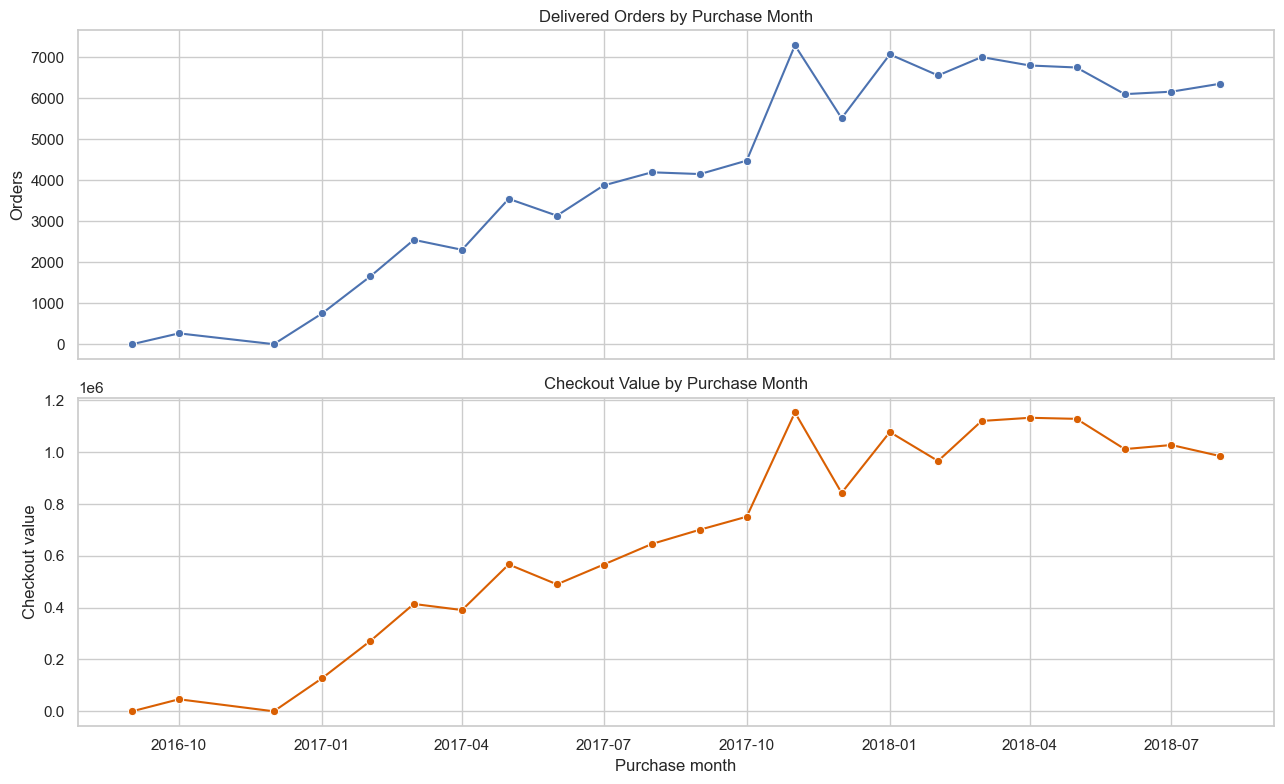

,month,realized_orders,checkout_value,avg_checkout_value
0,2016-09-01,1,143.46,143.46
1,2016-10-01,265,"46,490.66",175.44
2,2016-12-01,1,19.62,19.62
3,2017-01-01,750,"127,482.37",169.98
4,2017-02-01,1653,"271,239.32",164.09
5,2017-03-01,2546,"414,330.95",162.74
6,2017-04-01,2303,"390,812.40",169.70
7,2017-05-01,3546,"566,851.40",159.86
8,2017-06-01,3135,"490,050.37",156.32
9,2017-07-01,3872,"566,299.08",146.25


In [12]:
monthly = (delivered_orders.assign(month=delivered_orders['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp())
    .groupby('month', as_index=False)
    .agg(realized_orders=('order_id', 'nunique'),
         checkout_value=('order_item_total', 'sum'),
         avg_checkout_value=('order_item_total', 'mean')))
monthly.to_csv(TABLE_DIR / '03_monthly_sales_trend.csv', index=False)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
sns.lineplot(data=monthly, x='month', y='realized_orders', marker='o', ax=axes[0])
axes[0].set(title='Delivered Orders by Purchase Month', xlabel='', ylabel='Orders')
sns.lineplot(data=monthly, x='month', y='checkout_value', marker='o', color='#d95f02', ax=axes[1])
axes[1].set(title='Checkout Value by Purchase Month', xlabel='Purchase month', ylabel='Checkout value')
fig.tight_layout()
fig.savefig(FIGURE_DIR / '03_monthly_orders_and_checkout_value.png', dpi=150, bbox_inches='tight')
plt.show()
display(monthly)

## 3. Product-category performance

Category names are retained exactly as supplied. `unknown` signals missing product catalog classification and must remain visible in the result.

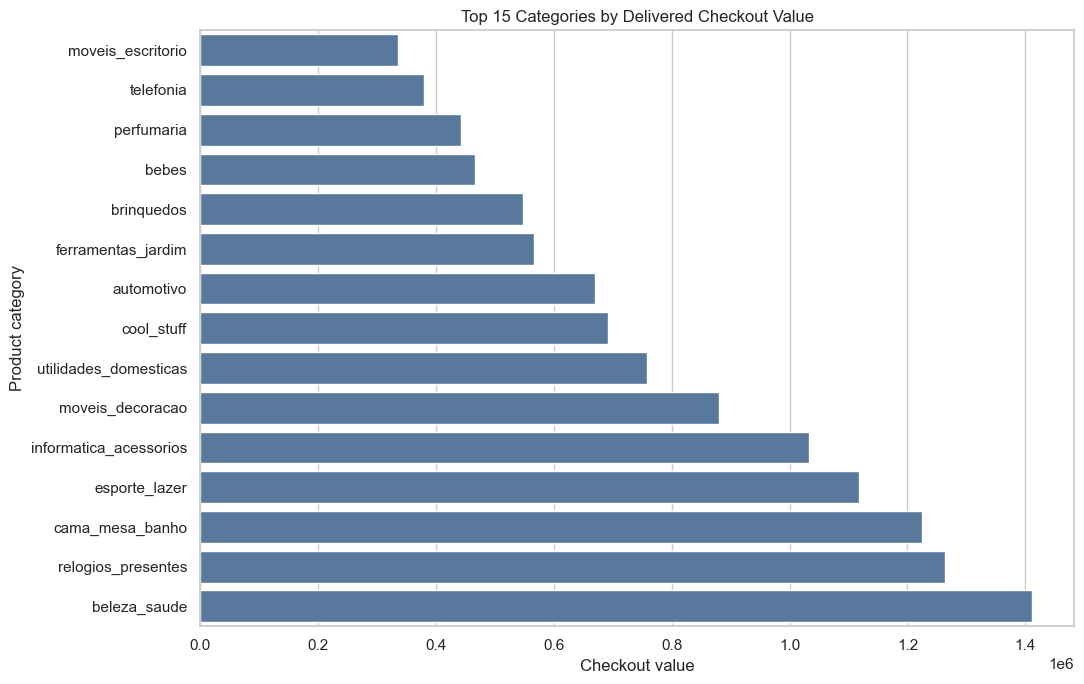

,product_category_name,items_sold,orders,merchandise_value,checkout_value,avg_item_price
11,beleza_saude,9465,8647,"1,233,131.72","1,412,089.53",130.28
66,relogios_presentes,5859,5495,"1,166,176.98","1,264,333.12",199.04
13,cama_mesa_banho,10953,9272,"1,023,434.76","1,225,209.26",93.44
32,esporte_lazer,8431,7530,"954,852.55","1,118,256.91",113.25
44,informatica_acessorios,7644,6530,"888,724.61","1,032,723.77",116.26
54,moveis_decoracao,8160,6307,"711,927.69","880,329.92",87.25
73,utilidades_domesticas,6795,5743,"615,628.69","758,392.25",90.60
26,cool_stuff,3718,3559,"610,204.10","691,680.89",164.12
8,automotivo,4140,3810,"578,966.65","669,454.75",139.85
40,ferramentas_jardim,4268,3448,"470,495.28","567,145.68",110.24


In [13]:
category_performance = (delivered_items.groupby('product_category_name', dropna=False, as_index=False)
    .agg(items_sold=('order_item_id', 'size'),
         orders=('order_id', 'nunique'),
         merchandise_value=('price', 'sum'),
         checkout_value=('item_total_value', 'sum'),
         avg_item_price=('price', 'mean'))
    .sort_values('checkout_value', ascending=False))
category_performance.to_csv(TABLE_DIR / '03_category_performance.csv', index=False)
top_categories = category_performance.head(15).sort_values('checkout_value')
plt.figure(figsize=(11, 7))
sns.barplot(data=top_categories, x='checkout_value', y='product_category_name', color='#4c78a8')
plt.title('Top 15 Categories by Delivered Checkout Value')
plt.xlabel('Checkout value')
plt.ylabel('Product category')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '03_top_categories_by_checkout_value.png', dpi=150, bbox_inches='tight')
plt.show()
display(category_performance.head(15))

## 4. Customer geography

Customer state is attached at order level, then values are aggregated. We do not count item rows as orders.

In [14]:
delivered_with_customer = delivered_orders.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']],
    on='customer_id', how='left', validate='one_to_one'
)
state_performance = (delivered_with_customer.groupby('customer_state', as_index=False)
    .agg(realized_orders=('order_id', 'nunique'),
         unique_customers=('customer_unique_id', 'nunique'),
         checkout_value=('order_item_total', 'sum'),
         avg_checkout_value=('order_item_total', 'mean'))
    .sort_values('checkout_value', ascending=False))
state_performance.to_csv(TABLE_DIR / '03_customer_state_performance.csv', index=False)
display(state_performance.head(15))

,customer_state,realized_orders,unique_customers,checkout_value,avg_checkout_value
25,SP,40501,39156,"5,769,703.15",142.46
18,RJ,12350,11917,"2,055,401.57",166.43
10,MG,11354,11001,"1,818,891.67",160.20
22,RS,5345,5168,"861,472.79",161.17
17,PR,4923,4769,"781,708.80",158.79
23,SC,3546,3449,"595,127.78",167.83
4,BA,3256,3158,"591,137.81",181.55
6,DF,2080,2019,"346,123.35",166.41
8,GO,1957,1895,"334,212.35",170.78
7,ES,1995,1928,"317,657.93",159.23


## 5. Seller contribution

This is item-grain analysis. Seller checkout value is the sum of delivered item price plus freight; it does not claim profit, because costs and commissions are absent.

In [15]:
seller_performance = (delivered_items.groupby(['seller_id', 'seller_state'], as_index=False)
    .agg(items_sold=('order_item_id', 'size'),
         orders=('order_id', 'nunique'),
         checkout_value=('item_total_value', 'sum'),
         avg_item_value=('item_total_value', 'mean'))
    .sort_values('checkout_value', ascending=False))
seller_performance.to_csv(TABLE_DIR / '03_seller_performance.csv', index=False)
display(seller_performance.head(15))

,seller_id,seller_state,items_sold,orders,checkout_value,avg_item_value
834,4869f7a5dfa277a7dca6462dcf3b52b2,SP,1148,1124,"247,007.06",215.16
1480,7c67e1448b00f6e969d365cea6b010ab,SP,1355,973,"237,806.69",175.50
858,4a3ca9315b744ce9f8e9374361493884,SP,1949,1772,"231,220.43",118.64
982,53243585a1d6dc2643021fd1853d8905,BA,400,348,"230,797.02",576.99
2903,fa1c13f2614d7b5c4749cbc52fecda94,SP,579,578,"200,833.50",346.86
2543,da8622b14eb17ae2831f4ac5b9dab84a,SP,1548,1311,"184,706.78",119.32
1504,7e93a43ef30c4f03f38b393420bc753a,SP,322,319,"171,973.55",534.08
188,1025f0e2d44d7041d6cf58b6550e0bfa,SP,1420,910,"171,924.96",121.07
1450,7a67c85e85bb2ce8582c35f2203ad736,SP,1155,1145,"160,278.52",138.77
1758,955fee9216a65b617aa5c0531780ce60,SP,1472,1261,"156,606.48",106.39


## 6. Delivery performance

Only `delivered` orders with valid delivery timelines enter duration and late-delivery metrics. Cancelled orders with delivery dates are retained in raw data but excluded from this operational KPI.

,customer_state,delivered_orders,avg_delivery_days,median_delivery_days,late_delivery_rate
2,AM,145,26.43,25.88,0.04
1,AL,397,24.54,22.33,0.24
13,PA,946,23.77,21.08,0.12
9,MA,717,21.57,19.19,0.20
24,SE,335,21.52,18.01,0.15
5,CE,1279,21.27,18.21,0.15
14,PB,517,20.43,18.15,0.11
16,PI,476,19.46,16.29,0.16
20,RO,243,19.37,17.58,0.03
4,BA,3256,19.34,16.91,0.14


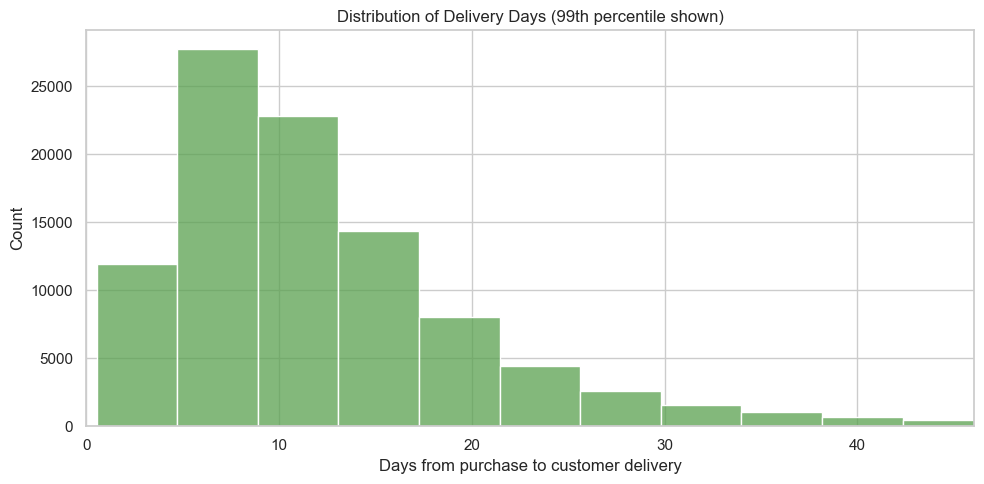

In [16]:
delivery = delivered_with_customer.query('valid_delivery_timeline').copy()
delivery_by_state = (delivery.groupby('customer_state', as_index=False)
    .agg(delivered_orders=('order_id', 'nunique'),
         avg_delivery_days=('delivery_days_valid', 'mean'),
         median_delivery_days=('delivery_days_valid', 'median'),
         late_delivery_rate=('is_late', 'mean'))
    .query('delivered_orders >= 100')
    .sort_values('avg_delivery_days', ascending=False))
delivery_by_state.to_csv(TABLE_DIR / '03_delivery_by_customer_state.csv', index=False)
display(delivery_by_state.head(15))

plt.figure(figsize=(10, 5))
sns.histplot(delivery['delivery_days_valid'], bins=50, color='#59a14f')
plt.xlim(0, delivery['delivery_days_valid'].quantile(0.99))
plt.title('Distribution of Delivery Days (99th percentile shown)')
plt.xlabel('Days from purchase to customer delivery')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '03_delivery_days_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Payment behavior

Payment records are analysed at their own grain. This table answers payment-method questions; it is not joined to items for sales totals.

In [17]:
delivered_payment_ids = delivered_orders[['order_id']]
delivered_payments = payments.merge(delivered_payment_ids, on='order_id', how='inner', validate='many_to_one')
payment_behavior = (delivered_payments.groupby('payment_type', dropna=False, as_index=False)
    .agg(payment_records=('order_id', 'size'),
         orders=('order_id', 'nunique'),
         payment_value=('payment_value', 'sum'),
         avg_installments=('payment_installments', 'mean'))
    .sort_values('orders', ascending=False))
payment_behavior['order_share_pct'] = payment_behavior['orders'] / delivered_orders['order_id'].nunique() * 100
payment_behavior.to_csv(TABLE_DIR / '03_payment_behavior.csv', index=False)
display(payment_behavior)

,payment_type,payment_records,orders,payment_value,avg_installments,order_share_pct
1,credit_card,74586,74304,"12,101,094.88",3.50,77.02
0,boleto,19191,19191,"2,769,932.58",1.00,19.89
3,voucher,5493,3679,"343,013.19",1.00,3.81
2,debit_card,1486,1485,"208,421.12",1.00,1.54


## EDA handoff

Use the saved tables and figures to write evidence-based insights. In the next notebook we will study customer repeat behavior and RFM segmentation with `customer_unique_id`; this is the only customer identifier appropriate for repeat-customer analysis.